# GA Optimasi Posisi Object 2D COC

objek: Town hall, defense, storage, army

Aturan:
1. tidak boleh ada yang tumpang tindih

Setiap objek mempunyai posisi:
```
A = (x1, y1)
B = (x2, y2)
C = (x3, y3)
D = (x4, y4)
E = (x5, y5)
```

Individual
[
    (x, y, size),
    (x, y, size),
    ...
]

(x,y) menjadi koordinat pojok kiri bawah objek

### Contoh asli bangunan TH13

|	id	|	name	|	count	|	level	|	size	|	category	|	village	|
|	:------	|	:------	|	:------	|	:------	|	:------	|	:------	|	:------	|
|	1000001	|	Town Hall	|	1	|	13	|	[4, 4]	|	Town Hall	|	home	|
|	1000014	|	Clan Castle	|	1	|	9	|	[3, 3]	|	Army	|	home	|
|	1000031	|	Eagle Artillery	|	1	|	4	|	[4, 4]	|	Defense	|	home	|
|	1000067	|	Scattershot	|	2	|	2	|	[3, 3]	|	Defense	|	home	|
|	1000027	|	Inferno Tower	|	3	|	6	|	[2, 2]	|	Defense	|	home	|
|	1000021	|	X-Bow	|	4	|	5	|	[3, 3]	|	Defense	|	home	|
|	1000012	|	Air Defense	|	4	|	9	|	[3, 3]	|	Defense	|	home	|
|	1000028	|	Air Sweeper	|	2	|	7	|	[2, 2]	|	Defense	|	home	|
|	1000009	|	Archer Tower	|	8	|	15	|	[3, 3]	|	Defense	|	home	|
|	1000000	|	Army Camp	|	4	|	11	|	[4, 4]	|	Army	|	home	|
|	1000006	|	Barracks	|	1	|	15	|	[3, 3]	|	Army	|	home	|
|	1000070	|	Blacksmith	|	1	|	6	|	[3, 3]	|	Army	|	home	|
|	1000032	|	Bomb Tower	|	2	|	6	|	[3, 3]	|	Defense	|	home	|
|	1000015	|	Builder's Hut	|	5	|	1	|	[2, 2]	|	Worker	|	home	|
|	1000008	|	Cannon	|	7	|	19	|	[3, 3]	|	Defense	|	home	|
|	1000026	|	Dark Barracks	|	1	|	10	|	[3, 3]	|	Army	|	home	|
|	1000023	|	Dark Elixir Drill	|	3	|	9	|	[3, 3]	|	Resource	|	home	|
|	1000024	|	Dark Elixir Storage	|	1	|	8	|	[3, 3]	|	Resource	|	home	|
|	1000029	|	Dark Spell Factory	|	1	|	6	|	[3, 3]	|	Army	|	home	|
|	1000002	|	Elixir Collector	|	7	|	15	|	[3, 3]	|	Resource	|	home	|
|	1000003	|	Elixir Storage	|	4	|	14	|	[3, 3]	|	Resource	|	home	|
|	1000004	|	Gold Mine	|	7	|	15	|	[3, 3]	|	Resource	|	home	|
|	1000005	|	Gold Storage	|	4	|	14	|	[3, 3]	|	Resource	|	home	|
|	1000093	|	Helper Hut	|	1	|	1	|	[3, 3]	|	Helper	|	home	|
|	1000071	|	Hero Hall	|	1	|	7	|	[4, 4]	|	Army	|	home	|
|	1000019	|	Hidden Tesla	|	5	|	9	|	[2, 2]	|	Defense	|	home	|
|	1000007	|	Laboratory	|	1	|	11	|	[3, 3]	|	Army	|	home	|
|	1000013	|	Mortar	|	4	|	12	|	[3, 3]	|	Defense	|	home	|
|	1000020	|	Spell Factory	|	1	|	7	|	[3, 3]	|	Army	|	home	|
|	1000010	|	Wall	|	300	|	14	|	[1, 1]	|	Wall	|	home	|
|	1000011	|	Wizard Tower	|	5	|	10	|	[3, 3]	|	Defense	|	home	|
|	1000059	|	Workshop	|	1	|	5	|	[4, 4]	|	Army	|	home	|


In [14]:
import random
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [15]:
village = {
  "townhall_level": 13,
  "building_count": 393,
  "wall_count": 300,
  "map_size": 44,
  "buildings": [
    {
      "id": 1000001,
      "name": "Town Hall",
      "level": 13,
      "size": [4, 4],
      "category": "Town Hall",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000014,
      "name": "Clan Castle",
      "level": 9,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000031,
      "name": "Eagle Artillery",
      "level": 4,
      "size": [4, 4],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000067,
      "name": "Scattershot",
      "level": 2,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000067,
      "name": "Scattershot",
      "level": 2,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000027,
      "name": "Inferno Tower",
      "level": 6,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000027,
      "name": "Inferno Tower",
      "level": 6,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000027,
      "name": "Inferno Tower",
      "level": 6,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000028,
      "name": "Air Sweeper",
      "level": 7,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000028,
      "name": "Air Sweeper",
      "level": 7,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 8
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000006,
      "name": "Barracks",
      "level": 15,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000070,
      "name": "Blacksmith",
      "level": 6,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000032,
      "name": "Bomb Tower",
      "level": 6,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000032,
      "name": "Bomb Tower",
      "level": 6,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000026,
      "name": "Dark Barracks",
      "level": 10,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000023,
      "name": "Dark Elixir Drill",
      "level": 9,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000023,
      "name": "Dark Elixir Drill",
      "level": 9,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000023,
      "name": "Dark Elixir Drill",
      "level": 9,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000024,
      "name": "Dark Elixir Storage",
      "level": 8,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000029,
      "name": "Dark Spell Factory",
      "level": 6,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000093,
      "name": "Helper Hut",
      "level": 1,
      "size": [3, 3],
      "category": "Helper",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000071,
      "name": "Hero Hall",
      "level": 7,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000007,
      "name": "Laboratory",
      "level": 11,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000020,
      "name": "Spell Factory",
      "level": 7,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000059,
      "name": "Workshop",
      "level": 5,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 1
    }
  ]
}


In [46]:
# =========================================
# 1. Parameter Genetic Algorithm
# =========================================

POPULATION_SIZE = 50
GENERATIONS = 250
MUTATION_RATE = 0.1

GRID_SIZE = 44

OVERLAP_PENALTY = 1000
BOUNDARY_PENALTY = 1000

BUILDINGS = village["buildings"]
NUMBER_OF_OBJECTS = len(BUILDINGS)


In [50]:
total_area = sum(
    building["size"][0] * building["size"][1]
    for building in BUILDINGS
)

print("Total building area:", total_area)
print("Map area:", GRID_SIZE * GRID_SIZE)

Total building area: 818
Map area: 1936


In [18]:
# =========================================
# Fungsi Distance
# =========================================

def distance(point1, point2):

    x1, y1 = point1
    x2, y2 = point2

    return math.sqrt(
        (x2 - x1) ** 2 +
        (y2 - y1) ** 2
    )
    
# =========================================
# Fungsi Overlap bangunan 2D
# =========================================
def is_overlap(pos1, size1, pos2, size2):

    x1, y1 = pos1
    w1, h1 = size1

    x2, y2 = pos2
    w2, h2 = size2

    return (
        x1 < x2 + w2 and
        x1 + w1 > x2 and
        y1 < y2 + h2 and
        y1 + h1 > y2
    )


# =========================================
# 2. Fungsi Fitness
# =========================================

def fitness(individual):

    penalty = 0

    # ==============================
    # Boundary
    # ==============================

    for i, building in enumerate(BUILDINGS):

        x, y = individual[i]

        width, height = building["size"]

        if x < 0:
            penalty += BOUNDARY_PENALTY

        if y < 0:
            penalty += BOUNDARY_PENALTY

        if x + width > GRID_SIZE:
            penalty += BOUNDARY_PENALTY

        if y + height > GRID_SIZE:
            penalty += BOUNDARY_PENALTY


    # ==============================
    # Overlap
    # ==============================

    for i in range(NUMBER_OF_OBJECTS):

        for j in range(i + 1, NUMBER_OF_OBJECTS):

            if is_overlap(
                individual[i],
                BUILDINGS[i]["size"],
                individual[j],
                BUILDINGS[j]["size"]
            ):
                penalty += OVERLAP_PENALTY


    return -penalty


# =========================================
# 3. Membuat individual
# =========================================

def create_individual():

    individual = []

    for building in BUILDINGS:

        width, height = building["size"]

        max_x = GRID_SIZE - width
        max_y = GRID_SIZE - height

        x = random.randint(0, max_x)
        y = random.randint(0, max_y)

        individual.append((x, y))

    return individual

In [19]:
# =========================================
# 5. Membuat population
# =========================================

def create_population():
    return [
        create_individual()
        for _ in range(POPULATION_SIZE)
    ]


# =========================================
# 6. Selection
# =========================================

def selection(population):
    population_sorted = sorted(
        population,
        key=fitness,
        reverse=True
    )

    # Ambil 50% terbaik
    return population_sorted[:POPULATION_SIZE // 2]


# =========================================
# 7. Crossover
# =========================================
def crossover(parent1, parent2):

    child1 = []
    child2 = []

    for i in range(NUMBER_OF_OBJECTS):

        if random.random() < 0.5:

            child1.append(parent1[i])
            child2.append(parent2[i])

        else:

            child1.append(parent2[i])
            child2.append(parent1[i])

    return child1, child2

# =========================================
# 8. Mutation
# =========================================
def mutation(individual):

    for i in range(NUMBER_OF_OBJECTS):

        if random.random() < MUTATION_RATE:

            width, height = BUILDINGS[i]["size"]

            max_x = GRID_SIZE - width
            max_y = GRID_SIZE - height

            x = random.randint(0, max_x)
            y = random.randint(0, max_y)

            individual[i] = (x, y)

    return individual




Generation 01 | Fitness = -39000.00 | Position = [(24, 33), (41, 28), (25, 37), (34, 39), (10, 0), (30, 41), (11, 9), (35, 19), (26, 3), (9, 2), (39, 37), (5, 21), (19, 12), (15, 23), (38, 13), (15, 2), (42, 19), (42, 6), (1, 41), (27, 12), (6, 12), (39, 24), (5, 34), (17, 15), (2, 2), (24, 11), (1, 29), (10, 14), (4, 8), (8, 27), (9, 37), (4, 27), (21, 15), (2, 19), (36, 40), (32, 9), (21, 29), (29, 35), (39, 20), (40, 34), (34, 38), (20, 39), (34, 35), (7, 31), (40, 6), (29, 37), (34, 0), (37, 30), (11, 41), (11, 15), (29, 33), (11, 1), (39, 3), (16, 25), (0, 14), (10, 7), (34, 0), (20, 33), (37, 12), (18, 12), (34, 25), (13, 19), (33, 3), (13, 1), (41, 25), (18, 41), (5, 37), (13, 8), (6, 32), (5, 26), (23, 5), (33, 7), (1, 37), (22, 23), (6, 0), (33, 19), (15, 39), (24, 34), (27, 5), (12, 24), (28, 28), (26, 35), (10, 30), (27, 17), (2, 17), (28, 16), (31, 37), (15, 25), (12, 20), (25, 5), (17, 35), (37, 16), (29, 30)]
Generation 02 | Fitness = -39000.00 | Position = [(24, 33), (41

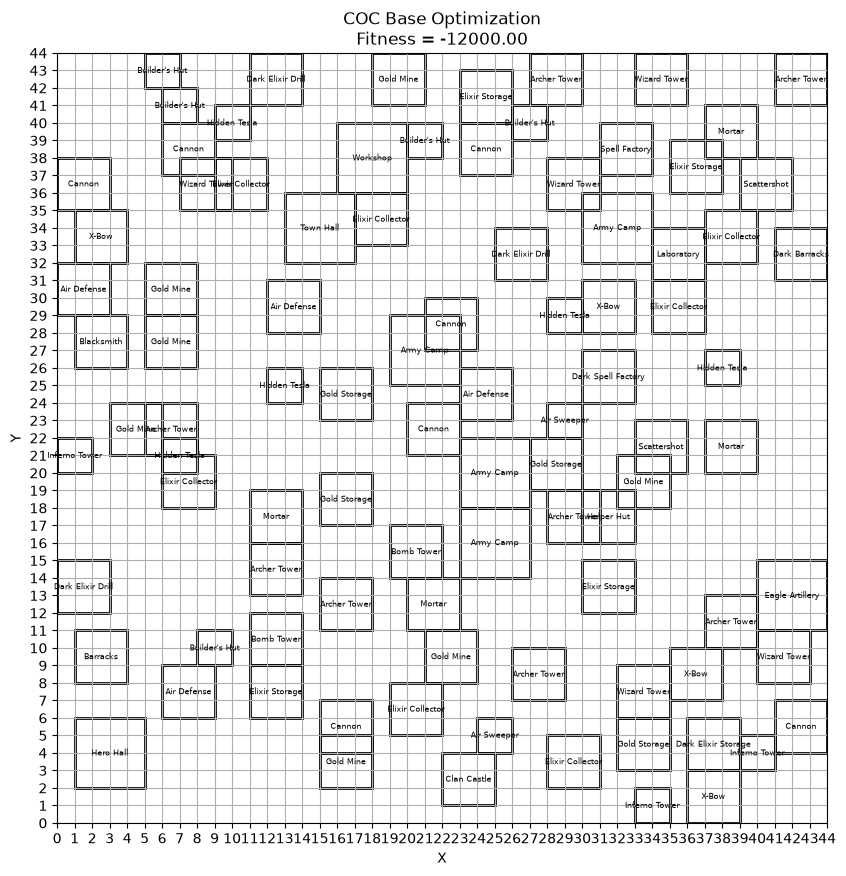

In [47]:
# =========================================
# 9. Genetic Algorithm
# =========================================

population = create_population()


for generation in range(GENERATIONS):

    # -----------------------------
    # Evaluasi
    # -----------------------------

    best = max(
        population,
        key=fitness
    )

    print(
        f"Generation {generation + 1:02d} | "
        f"Fitness = {fitness(best):.2f} | "
        f"Position = {best}"
    )


    # -----------------------------
    # Selection
    # -----------------------------

    parents = selection(population)


    # -----------------------------
    # Membuat population baru
    # -----------------------------

    new_population = parents.copy()


    while len(new_population) < POPULATION_SIZE:

        parent1, parent2 = random.sample(parents, 2)

        child1, child2 = crossover(
            parent1,
            parent2
        )

        child1 = mutation(child1)
        child2 = mutation(child2)

        new_population.append(child1)

        if len(new_population) < POPULATION_SIZE:
            new_population.append(child2)


    population = new_population


# =========================================
# 10. Hasil akhir
# =========================================

best = max(
    population,
    key=fitness
)

print("\nHasil Akhir")

print("Position :", best)
print("Fitness  :", fitness(best))



# =========================================
# 11. Visualisasi
# =========================================

fig, ax = plt.subplots(figsize=(10, 10))

for i, (x, y) in enumerate(best):

    # Ambil ukuran dari dataset
    width, height = BUILDINGS[i]["size"]

    rectangle = Rectangle(
        (x, y),
        width,
        height,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

    ax.text(
        x + width / 2,
        y + height / 2,
        # f"{i + 1}",
        BUILDINGS[i]["name"],
        ha="center",
        va="center",
        fontsize=6
    )


# =========================================
# Map
# =========================================

ax.set_xlim(0, GRID_SIZE)
ax.set_ylim(0, GRID_SIZE)

ax.set_xticks(range(GRID_SIZE + 1))
ax.set_yticks(range(GRID_SIZE + 1))

ax.grid(True)

ax.set_aspect("equal")

ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.set_title(
    f"COC Base Optimization\n"
    f"Fitness = {fitness(best):.2f}"
)

plt.show()